# **ML Model:** Random Forest

## **Notes:**

**Random Forest** is an ensemble of decision trees trained on random subsets of data and features (bagging).

It serves as the first advanced model compared against the Logistic Regression baseline.

Key advantages over logistic regression for this problem:
- Captures non-linear relationships (e.g. spatial clusters from lat/lon)
- Handles feature interactions automatically
- Robust to outliers and does not require feature scaling
- Provides feature importance out of the box

Hyperparameter tuning is done via **RandomizedSearchCV** with cross-validation.

## **Implementation:**

#### Librabry imports

In [2]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier

In [3]:
sys.path.append(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'scripts'))

In [4]:
from utils import eval_model, print_report, save_results, load_results, load_info, split_info # type: ignore

### **Load data**

In [5]:
data = pd.read_excel('../data/processed/accident_processed_srb.xlsx')

In [6]:
load_info(df=data)

Shape: (205352, 16)
Columns: ['municipality', 'longitude', 'latitude', 'accident_type', 'month', 'day_of_week', 'hour', 'day_type', 'is_rush', 'is_night', 'season', 'acc_parked_vehicles', 'acc_pedestrians', 'acc_single_vehicle', 'acc_two_vehicles_no_turn', 'acc_two_vehicles_turn_or_cross']
Number of coumnts: 16
Target distribution: accident_type
0    0.597
1    0.403
Name: proportion, dtype: float64


In [7]:
y = data['accident_type']
X = data.drop(columns=['accident_type'])

### **Split data**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
split_info(X_train, X_test, y_train, y_test)

Rows number (Train): 164281
Rows number (Test): 41071
Target distribution (Train): {0: 0.597, 1: 0.403}
Target distribution (Test): {0: 0.597, 1: 0.403}


Target encoding for municipality — consistent with previous models.

In [10]:
mun_encoder = ce.TargetEncoder(cols=['municipality'])

In [11]:
X_train['municipality'] = mun_encoder.fit_transform(X_train['municipality'], y_train)
X_test['municipality'] = mun_encoder.transform(X_test['municipality'])

### **Training**

In [12]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

In [13]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### **Evaluation**

In [14]:
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

In [15]:
results = eval_model(
    model_name = 'Random Forest (Baseline)',
    y_test = y_test,
    y_pred = y_pred, 
    y_pred_prob = y_pred_prob,
    target_names = ['Material', 'Injured/Dead']
)

In [16]:
print_report(
    y_test = y_test, 
    y_pred = y_pred, 
    results = results, 
    target_names = ['Material', 'Injured/Dead']
)

Random Forest (Baseline)
              precision    recall  f1-score   support

    Material       0.73      0.82      0.77     24509
Injured/Dead       0.67      0.56      0.61     16562

    accuracy                           0.71     41071
   macro avg       0.70      0.69      0.69     41071
weighted avg       0.71      0.71      0.71     41071

ROC-AUC value: 0.7798


### **Additional:**

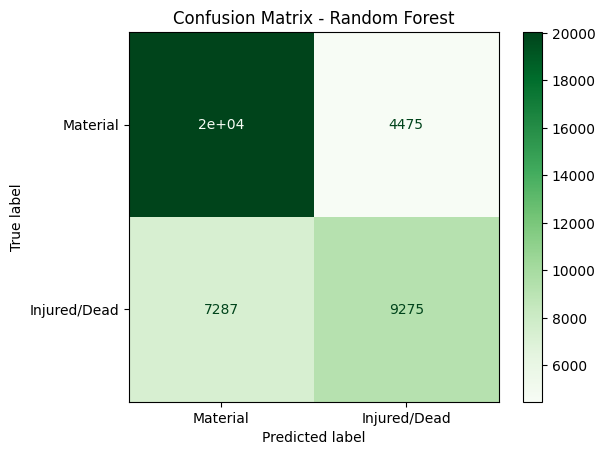

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Material', 'Injured/Dead'],
    cmap='Greens'
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

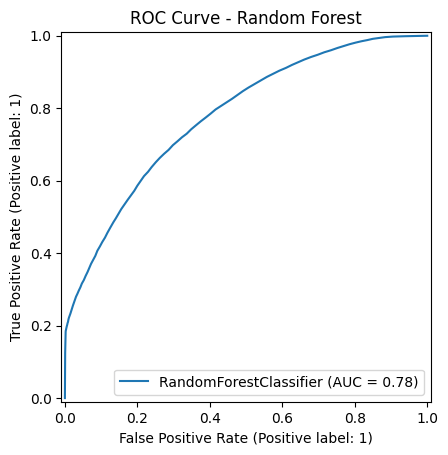

In [18]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

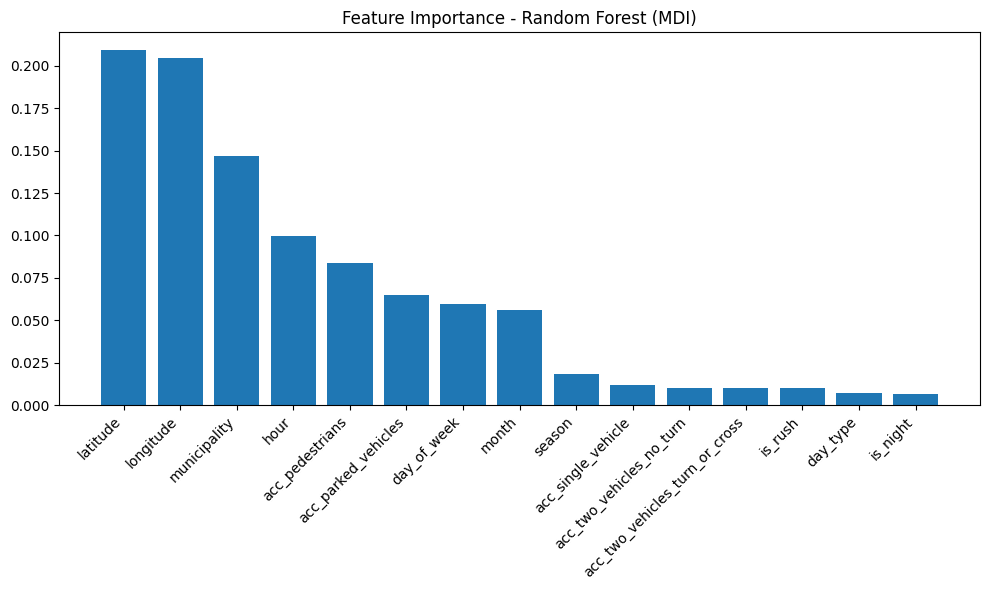

latitude                            0.2093
longitude                           0.2045
municipality                        0.1470
hour                                0.0998
acc_pedestrians                     0.0838
acc_parked_vehicles                 0.0649
day_of_week                         0.0598
month                               0.0563
season                              0.0186
acc_single_vehicle                  0.0120
acc_two_vehicles_no_turn            0.0101
acc_two_vehicles_turn_or_cross      0.0101
is_rush                             0.0100
day_type                            0.0070
is_night                            0.0066


In [19]:
feature_names = X_train.columns
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha='right')
plt.title("Feature Importance - Random Forest (MDI)")
plt.tight_layout()
plt.show()

# %%
for i in sorted_idx:
    print(f"{feature_names[i]:<35} {importances[i]:.4f}")

In [20]:
save_results(results)

In [21]:
joblib.dump(rf_model, '../models/random_forest_baseline.pkl')
joblib.dump(mun_encoder, '../models/encoders/rf_mun_target_encoder.pkl')

['../models/encoders/rf_mun_target_encoder.pkl']

### **Tuning**

In [22]:
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter = 40,
    scoring = 'roc_auc',
    cv = cv,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

In [24]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [10, 15, ...], 'max_features': ['sqrt', 0.3], 'min_samples_leaf': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [25]:
print("Best parameters:")
print(rf_search.best_params_)
print(f"\nBest CV AUC: {rf_search.best_score_:.4f}")

rf_model = rf_search.best_estimator_

Best parameters:
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced_subsample'}

Best CV AUC: 0.8020


In [26]:
y_pred = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

In [27]:
results = eval_model(
    model_name = 'Random Forest (Tuned)',
    y_test = y_test,
    y_pred = y_pred,
    y_pred_prob = y_pred_prob,
    target_names = ['Material', 'Injured/Dead']
)

In [28]:
print_report(
    y_test = y_test,
    y_pred = y_pred,
    results = results,
    target_names = ['Material', 'Injured/Dead']
)

Random Forest (Tuned)
              precision    recall  f1-score   support

    Material       0.79      0.74      0.76     24509
Injured/Dead       0.64      0.71      0.67     16562

    accuracy                           0.72     41071
   macro avg       0.72      0.72      0.72     41071
weighted avg       0.73      0.72      0.73     41071

ROC-AUC value: 0.8027


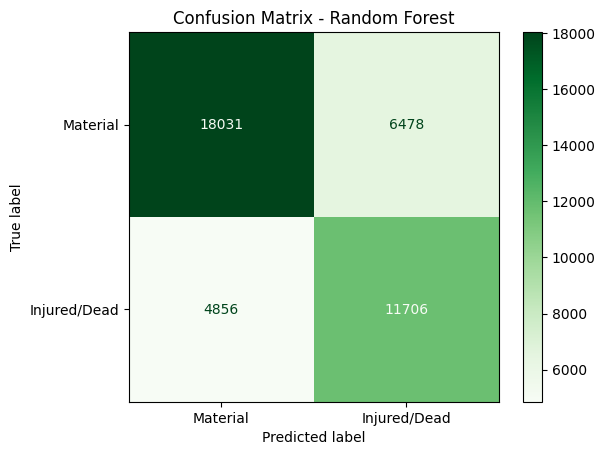

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Material', 'Injured/Dead'],
    cmap='Greens'
)
plt.title("Confusion Matrix - Random Forest")
plt.show()

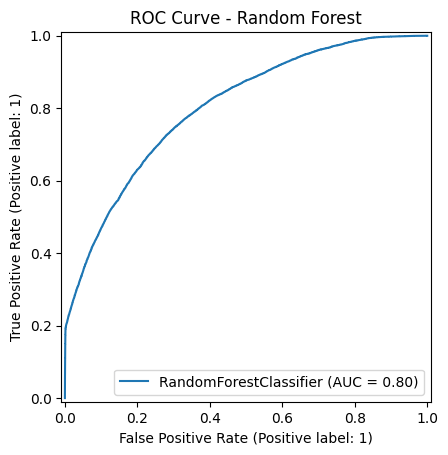

In [30]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

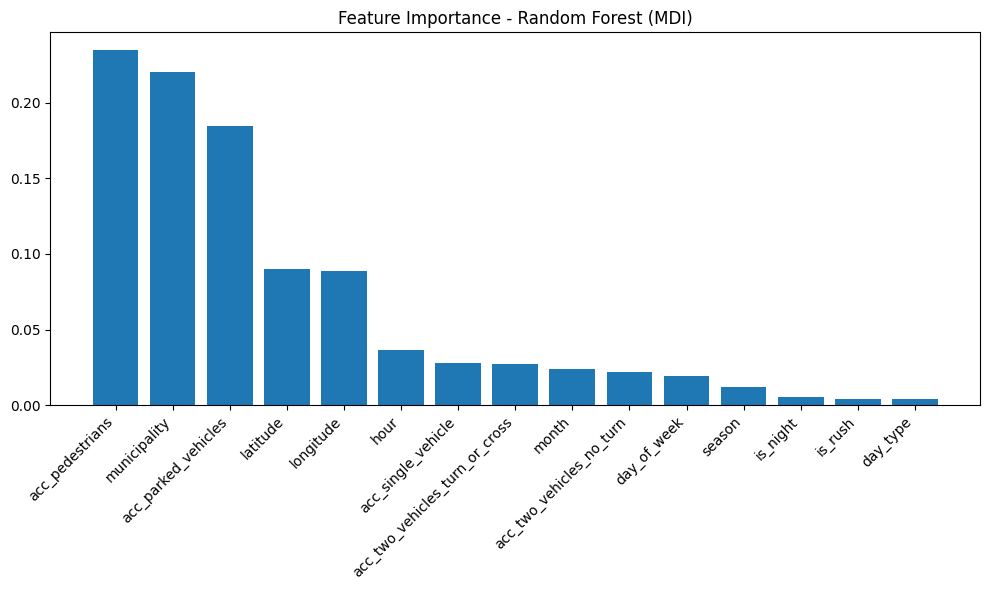

acc_pedestrians                     0.2348
municipality                        0.2204
acc_parked_vehicles                 0.1848
latitude                            0.0900
longitude                           0.0884
hour                                0.0364
acc_single_vehicle                  0.0278
acc_two_vehicles_turn_or_cross      0.0270
month                               0.0240
acc_two_vehicles_no_turn            0.0217
day_of_week                         0.0191
season                              0.0120
is_night                            0.0054
is_rush                             0.0041
day_type                            0.0040


In [31]:
feature_names = X_train.columns
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha='right')
plt.title("Feature Importance - Random Forest (MDI)")
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f"{feature_names[i]:<35} {importances[i]:.4f}")

In [32]:
save_results(results)

In [33]:
joblib.dump(rf_model,    '../models/random_forest_tuned.pkl')

['../models/random_forest_tuned.pkl']